In [1]:
import pandas as pd

In [3]:
df = pd.read_csv(r"C:\Users\Shivalika\Desktop\Zomato_EDA_Project\zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [4]:
df.shape

(51717, 17)

In [5]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [7]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [8]:
df = df.drop(['url', 'phone', 'dish_liked'], axis=1)
df.shape

(51717, 14)

In [9]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [10]:
def clean_rate(value):
    if value == 'NEW' or value == '-' or pd.isnull(value):
        return None
    else:
        value = str(value).split('/')[0]  # take only the part before '/'
        value = value.strip()              # remove any extra spaces
        return float(value)                # convert text to a decimal number

df['rate'] = df['rate'].apply(clean_rate)
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [11]:
df['rate'].head(20)

0     4.1
1     4.1
2     3.8
3     3.7
4     3.8
5     3.8
6     3.6
7     4.6
8     4.0
9     4.2
10    4.1
11    4.2
12    4.2
13    4.0
14    3.8
15    3.8
16    3.9
17    3.8
18    3.9
19    3.1
Name: rate, dtype: float64

In [12]:
df['approx_cost(for two people)'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', nan, '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

In [13]:
def clean_cost(value):
    if pd.isnull(value):
        return value
    else:
        value = str(value)              # make sure it's text
        value = value.replace(',', '')  # remove the comma
        value = float(value)            # convert text to a number
        return value

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].apply(clean_cost)
df['approx_cost(for two people)'].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700.,   nan, 1400.,  180., 1350.,
       2200., 2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800.,
       3400.,   40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,
        469.,   70., 3200.,   60.,  560.,  240.,  360., 6000., 1050.,
       2300., 4100., 5000., 3700., 1650., 2700., 4500.,  140.])

In [15]:
df['approx_cost(for two people)'].head(20)

0     800.0
1     800.0
2     800.0
3     300.0
4     600.0
5     600.0
6     800.0
7     600.0
8     700.0
9     550.0
10    500.0
11    600.0
12    500.0
13    450.0
14    800.0
15    650.0
16    800.0
17    700.0
18    300.0
19    400.0
Name: approx_cost(for two people), dtype: float64

In [16]:
df = df.dropna(subset=['location', 'rest_type', 'cuisines'])
df.shape

(51466, 14)

In [17]:
df.duplicated().sum()

np.int64(43)

In [18]:
df = df.drop_duplicates()
df.shape

(51423, 14)

In [19]:
df = df.rename(columns={
    'approx_cost(for two people)': 'approx_cost(2)',
    'listed_in(type)': 'listed_type',
    'listed_in(city)': 'listed_city'
})
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'approx_cost(2)', 'reviews_list',
       'menu_item', 'listed_type', 'listed_city'],
      dtype='object')

In [20]:
df['rate'].describe()

count    41478.000000
mean         3.702158
std          0.439863
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

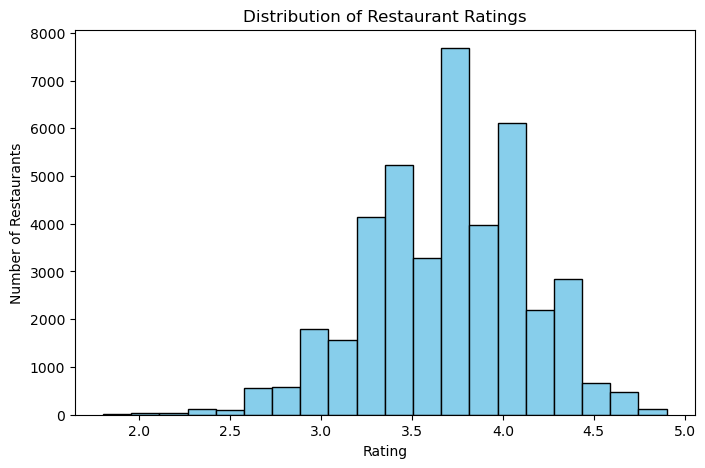

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['rate'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.show()

In [23]:
df['rest_type'].value_counts().head(10)

rest_type
Quick Bites           19111
Casual Dining         10318
Cafe                   3730
Delivery               2591
Dessert Parlor         2262
Takeaway, Delivery     2031
Casual Dining, Bar     1154
Bakery                 1140
Beverage Shop           864
Bar                     697
Name: count, dtype: int64

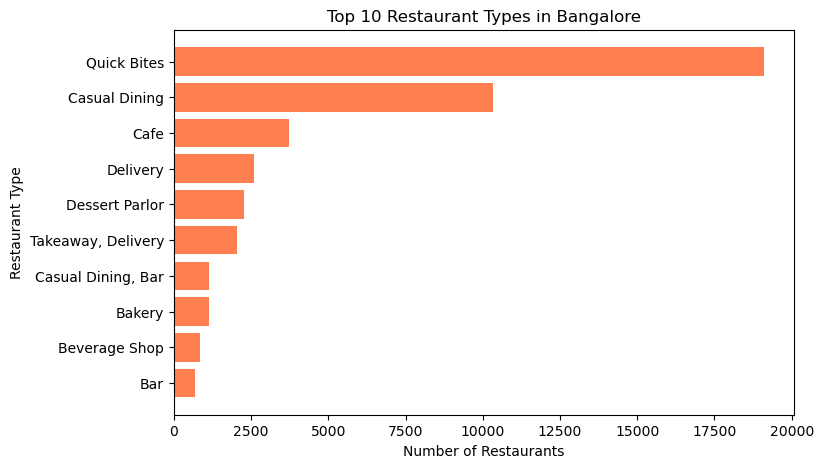

In [24]:
top_rest_types = df['rest_type'].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.barh(top_rest_types.index, top_rest_types.values, color='coral')
plt.title('Top 10 Restaurant Types in Bangalore')
plt.xlabel('Number of Restaurants')
plt.ylabel('Restaurant Type')
plt.gca().invert_yaxis()  # so the highest bar is at the top
plt.show()

In [25]:
df['online_order'].value_counts()

online_order
Yes    30277
No     21146
Name: count, dtype: int64

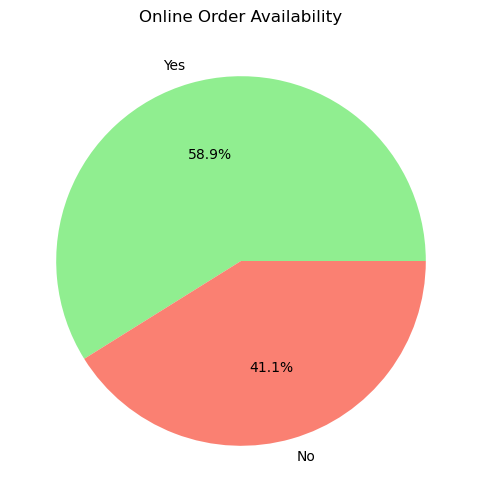

In [26]:
online_counts = df['online_order'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(online_counts.values, labels=online_counts.index, autopct='%1.1f%%', colors=['lightgreen','salmon'])
plt.title('Online Order Availability')
plt.show()

In [27]:
df['approx_cost(2)'].describe()

count    51106.000000
mean       556.061421
std        439.595426
min         40.000000
25%        300.000000
50%        400.000000
75%        700.000000
max       6000.000000
Name: approx_cost(2), dtype: float64

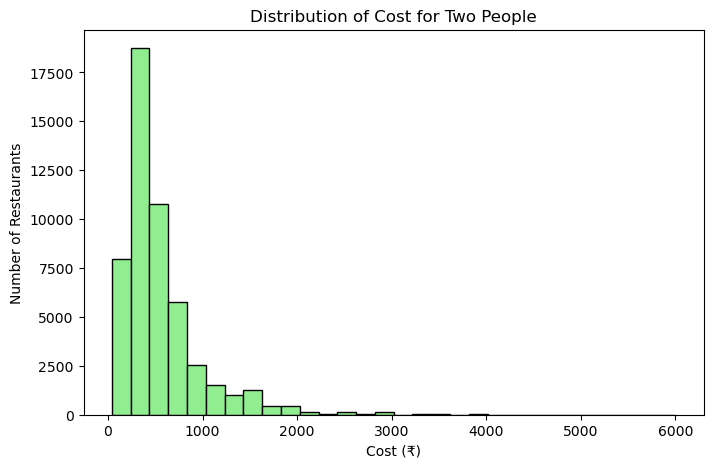

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df['approx_cost(2)'].dropna(), bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution of Cost for Two People')
plt.xlabel('Cost (₹)')
plt.ylabel('Number of Restaurants')
plt.show()

In [29]:
df.groupby('online_order')['rate'].mean()

online_order
No     3.661082
Yes    3.723995
Name: rate, dtype: float64

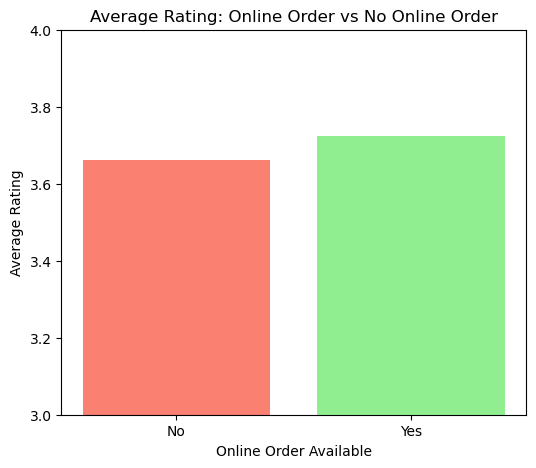

In [30]:
avg_rating_online = df.groupby('online_order')['rate'].mean()

plt.figure(figsize=(6,5))
plt.bar(avg_rating_online.index, avg_rating_online.values, color=['salmon','lightgreen'])
plt.title('Average Rating: Online Order vs No Online Order')
plt.xlabel('Online Order Available')
plt.ylabel('Average Rating')
plt.ylim(3, 4)
plt.show()

In [31]:
df.groupby('book_table')['rate'].mean()

book_table
No     3.623127
Yes    4.143531
Name: rate, dtype: float64

In [32]:
df.groupby('book_table')['approx_cost(2)'].mean()

book_table
No      452.856327
Yes    1271.608196
Name: approx_cost(2), dtype: float64

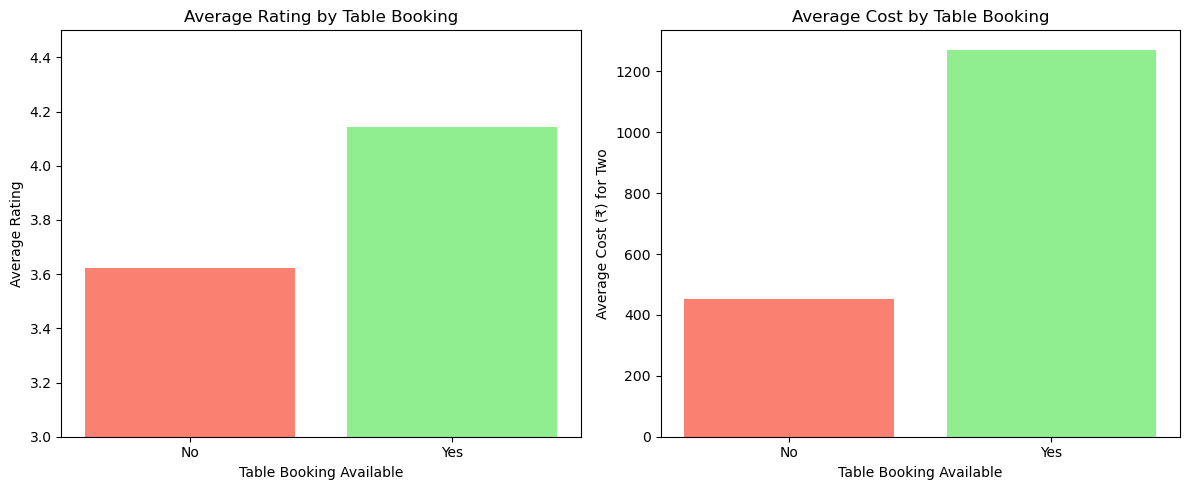

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Rating comparison
avg_rating_booking = df.groupby('book_table')['rate'].mean()
axes[0].bar(avg_rating_booking.index, avg_rating_booking.values, color=['salmon','lightgreen'])
axes[0].set_title('Average Rating by Table Booking')
axes[0].set_xlabel('Table Booking Available')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(3, 4.5)

# Cost comparison
avg_cost_booking = df.groupby('book_table')['approx_cost(2)'].mean()
axes[1].bar(avg_cost_booking.index, avg_cost_booking.values, color=['salmon','lightgreen'])
axes[1].set_title('Average Cost by Table Booking')
axes[1].set_xlabel('Table Booking Available')
axes[1].set_ylabel('Average Cost (₹) for Two')

plt.tight_layout()
plt.show()

In [34]:
df['location'].value_counts().head(10)

location
BTM                      5087
HSR                      2510
Koramangala 5th Block    2503
JP Nagar                 2221
Whitefield               2118
Indiranagar              2075
Jayanagar                1924
Marathahalli             1825
Bannerghatta Road        1624
Bellandur                1271
Name: count, dtype: int64

In [35]:
top_locations = df['location'].value_counts().head(10).index
df[df['location'].isin(top_locations)].groupby('location')['rate'].mean().sort_values(ascending=False)

location
Koramangala 5th Block    4.006083
Indiranagar              3.827757
Jayanagar                3.780256
JP Nagar                 3.677544
HSR                      3.676444
Whitefield               3.623140
BTM                      3.573646
Marathahalli             3.549754
Bellandur                3.531394
Bannerghatta Road        3.511048
Name: rate, dtype: float64

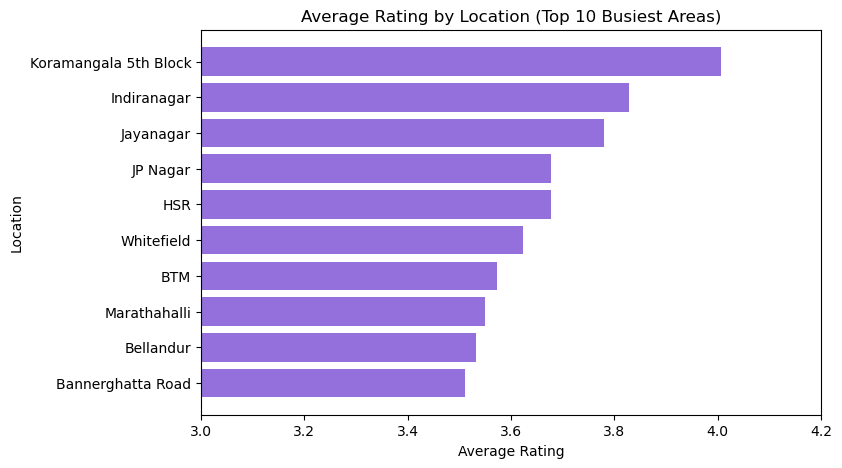

In [36]:
top_loc_ratings = df[df['location'].isin(top_locations)].groupby('location')['rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.barh(top_loc_ratings.index, top_loc_ratings.values, color='mediumpurple')
plt.title('Average Rating by Location (Top 10 Busiest Areas)')
plt.xlabel('Average Rating')
plt.ylabel('Location')
plt.gca().invert_yaxis()
plt.xlim(3, 4.2)
plt.show()

In [37]:
df['rate'].corr(df['approx_cost(2)'])

np.float64(0.3852610558305482)

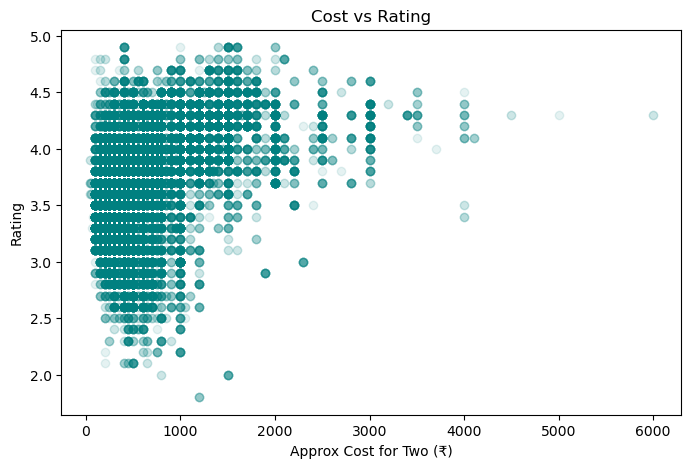

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(df['approx_cost(2)'], df['rate'], alpha=0.1, color='teal')
plt.title('Cost vs Rating')
plt.xlabel('Approx Cost for Two (₹)')
plt.ylabel('Rating')
plt.show()

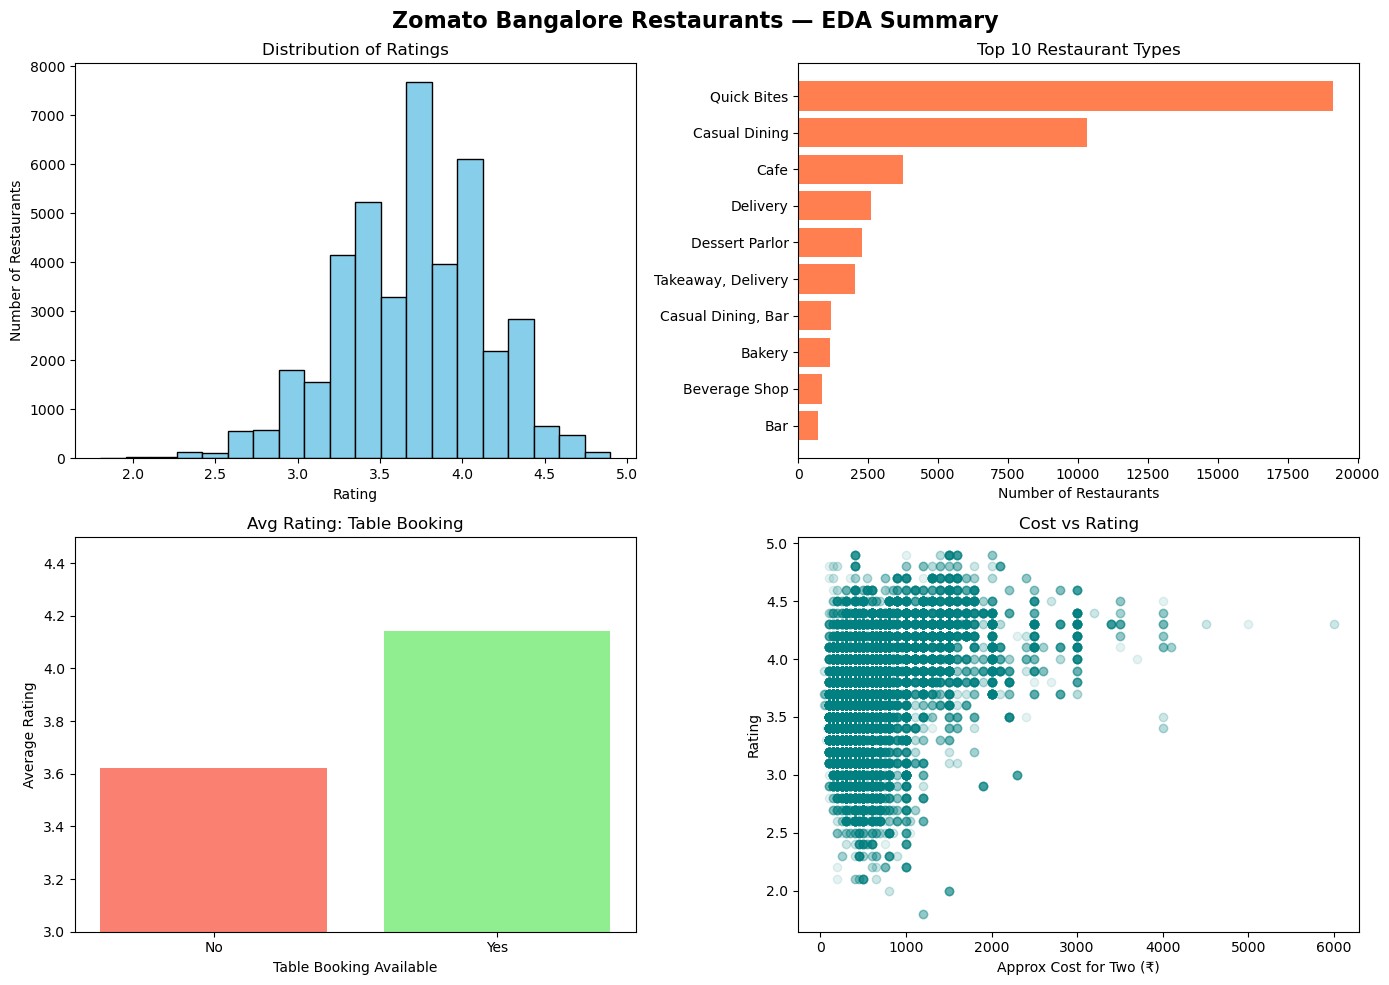

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Rating distribution
axes[0,0].hist(df['rate'].dropna(), bins=20, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribution of Ratings')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Number of Restaurants')

# 2. Top restaurant types
top_rest_types = df['rest_type'].value_counts().head(10)
axes[0,1].barh(top_rest_types.index, top_rest_types.values, color='coral')
axes[0,1].set_title('Top 10 Restaurant Types')
axes[0,1].set_xlabel('Number of Restaurants')
axes[0,1].invert_yaxis()

# 3. Table booking impact
avg_rating_booking = df.groupby('book_table')['rate'].mean()
axes[1,0].bar(avg_rating_booking.index, avg_rating_booking.values, color=['salmon','lightgreen'])
axes[1,0].set_title('Avg Rating: Table Booking')
axes[1,0].set_xlabel('Table Booking Available')
axes[1,0].set_ylabel('Average Rating')
axes[1,0].set_ylim(3, 4.5)

# 4. Cost vs Rating scatter
axes[1,1].scatter(df['approx_cost(2)'], df['rate'], alpha=0.1, color='teal')
axes[1,1].set_title('Cost vs Rating')
axes[1,1].set_xlabel('Approx Cost for Two (₹)')
axes[1,1].set_ylabel('Rating')

plt.suptitle('Zomato Bangalore Restaurants — EDA Summary', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('zomato_eda_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
import os
print(os.listdir())

['.anaconda', '.conda', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '.vscode-shared', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'edb_psqlodbc.exe', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{e343fe1c-1531-11f1-9b1a-ec3a56333455}.TM.blf', 'NTUSER.DAT{e343fe1c-1531-11f1-9b1a-ec3a56333455}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{e343fe1c-1531-11f1-9b1a-ec3a56333455}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Videos', 'Zomato_EDA draft1.ipynb', 'zomato_eda_summary.png']


## Key Insights

I analyzed about 51,000 restaurant listings from Zomato in Bangalore, looking at ratings, pricing, restaurant types, and how they relate to each other.

Most restaurants in Bangalore are rated decently — the average is 3.7/5, and most fall somewhere between 3.5 and 4.0. Very few restaurants are rated extremely low or extremely high.

The clearest pattern I found was around table booking. Restaurants that let you book a table in advance are rated noticeably higher (4.14 vs 3.62) and cost almost 3x more for two people (₹1,272 vs ₹453) than restaurants that don't. This was the strongest relationship in the whole dataset.

Online ordering also helps ratings a bit, but the effect is much smaller — 3.72 vs 3.66, basically a marginal bump.

One thing I didn't expect: having more restaurants in an area doesn't mean better restaurants. BTM has the most restaurants by far (5,087) but is actually near the bottom for average rating among busy areas (3.57). Koramangala 5th Block does better on both counts — high restaurant density and the best average rating (4.01).

Cost and rating are only loosely connected (correlation of 0.39). Spending more does improve your odds of a good meal, especially above ₹2,000, but plenty of cheap restaurants are highly rated too, so price alone isn't a reliable signal.

**Tools:** Python, Pandas, Matplotlib  
**Dataset:** Zomato Bangalore Restaurants, Kaggle (51,717 rows originally)